In [2]:
import pandas as pd

# load datasets
games = pd.read_csv("../dataset/games.csv")
sales = pd.read_csv("../dataset/vgsales.csv")

# preview data
print(games.head())
print(sales.head())

   Unnamed: 0                                    Title  Release Date  \
0           0                               Elden Ring  Feb 25, 2022   
1           1                                    Hades  Dec 10, 2019   
2           2  The Legend of Zelda: Breath of the Wild  Mar 03, 2017   
3           3                                Undertale  Sep 15, 2015   
4           4                            Hollow Knight  Feb 24, 2017   

                                                Team  Rating Times Listed  \
0     ['Bandai Namco Entertainment', 'FromSoftware']     4.5         3.9K   
1                               ['Supergiant Games']     4.3         2.9K   
2  ['Nintendo', 'Nintendo EPD Production Group No...     4.4         4.3K   
3                                 ['tobyfox', '8-4']     4.2         3.5K   
4                                    ['Team Cherry']     4.4           3K   

  Number of Reviews                                             Genres  \
0              3.9K           

In [3]:
print(games.head())

   Unnamed: 0                                    Title  Release Date  \
0           0                               Elden Ring  Feb 25, 2022   
1           1                                    Hades  Dec 10, 2019   
2           2  The Legend of Zelda: Breath of the Wild  Mar 03, 2017   
3           3                                Undertale  Sep 15, 2015   
4           4                            Hollow Knight  Feb 24, 2017   

                                                Team  Rating Times Listed  \
0     ['Bandai Namco Entertainment', 'FromSoftware']     4.5         3.9K   
1                               ['Supergiant Games']     4.3         2.9K   
2  ['Nintendo', 'Nintendo EPD Production Group No...     4.4         4.3K   
3                                 ['tobyfox', '8-4']     4.2         3.5K   
4                                    ['Team Cherry']     4.4           3K   

  Number of Reviews                                             Genres  \
0              3.9K           

In [4]:
games.drop(columns=['Unnamed: 0'], inplace=True, errors='ignore')

In [5]:
games.columns

Index(['Title', 'Release Date', 'Team', 'Rating', 'Times Listed',
       'Number of Reviews', 'Genres', 'Summary', 'Reviews', 'Plays', 'Playing',
       'Backlogs', 'Wishlist'],
      dtype='object')

In [6]:
games.isnull().sum()

Title                 0
Release Date          0
Team                  1
Rating               13
Times Listed          0
Number of Reviews     0
Genres                0
Summary               1
Reviews               0
Plays                 0
Playing               0
Backlogs              0
Wishlist              0
dtype: int64

In [7]:
games.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1512 entries, 0 to 1511
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Title              1512 non-null   object 
 1   Release Date       1512 non-null   object 
 2   Team               1511 non-null   object 
 3   Rating             1499 non-null   float64
 4   Times Listed       1512 non-null   object 
 5   Number of Reviews  1512 non-null   object 
 6   Genres             1512 non-null   object 
 7   Summary            1511 non-null   object 
 8   Reviews            1512 non-null   object 
 9   Plays              1512 non-null   object 
 10  Playing            1512 non-null   object 
 11  Backlogs           1512 non-null   object 
 12  Wishlist           1512 non-null   object 
dtypes: float64(1), object(12)
memory usage: 153.7+ KB


In [8]:
games['Rating'].fillna(games['Rating'].mean(), inplace=True)

C:\Users\gaura\AppData\Local\Temp\ipykernel_17816\3154177487.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  games['Rating'].fillna(games['Rating'].mean(), inplace=True)


In [9]:
games['Rating'] = games['Rating'].fillna(games['Rating'].mean())

In [10]:
games['rating'].isnull().sum()

KeyError: 'rating'

In [11]:
games.isnull().sum()

Title                0
Release Date         0
Team                 1
Rating               0
Times Listed         0
Number of Reviews    0
Genres               0
Summary              1
Reviews              0
Plays                0
Playing              0
Backlogs             0
Wishlist             0
dtype: int64

In [12]:
games['Team'].fillna('Unknown', inplace=True)

C:\Users\gaura\AppData\Local\Temp\ipykernel_17816\1944708610.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  games['Team'].fillna('Unknown', inplace=True)


In [13]:
games['Team'] = games['Team'].fillna('Unknown')

In [14]:
games['Summary'] = games['Summary'].fillna('No Summary Available')

In [15]:
games.isnull().sum()

Title                0
Release Date         0
Team                 0
Rating               0
Times Listed         0
Number of Reviews    0
Genres               0
Summary              0
Reviews              0
Plays                0
Playing              0
Backlogs             0
Wishlist             0
dtype: int64

In [16]:
games['Release Date'] = pd.to_datetime(games['Release Date'], errors='coerce')

In [17]:
games['Release Date'].dtype

dtype('<M8[ns]')

In [18]:
games['Year'] = games['Release Date'].dt.year

In [19]:
games['year'].head()

KeyError: 'year'

In [20]:
games['Year'].head()

0    2022.0
1    2019.0
2    2017.0
3    2015.0
4    2017.0
Name: Year, dtype: float64

In [21]:
games['Year'] = games['Year'].astype('Int64')

In [22]:
games['Year'].head()

0    2022
1    2019
2    2017
3    2015
4    2017
Name: Year, dtype: Int64

## Games released per year (Trend 📈)

In [23]:
games['Year'].value_counts().sort_index()

Year
1980      1
1982      1
1985      1
1986      4
1987      3
1988      5
1989      5
1990      6
1991     11
1992      6
1993     12
1994     11
1995     12
1996     15
1997     18
1998     16
1999     25
2000     15
2001     30
2002     22
2003     26
2004     37
2005     41
2006     32
2007     50
2008     44
2009     40
2010     58
2011     50
2012     60
2013     68
2014     59
2015     73
2016     75
2017     70
2018     77
2019     87
2020     74
2021     97
2022    132
2023     38
2024      1
2025      1
Name: count, dtype: Int64

- The number of games released per year has increased steadily over time.
- There is a noticeable rise in game releases after the year 2000.
- This indicates rapid growth in the gaming industry.
- The increasing trend also suggests higher demand and more developers entering the market.

## Top Rated Games ⭐

In [25]:
games.sort_values(by='Rating', ascending=False)[['Title', 'Rating']].head(10)

,Title,Rating
1252,Elden Ring: Shadow of the Erdtree,4.8
1090,The Great Ace Attorney 2: Resolve,4.6
1153,Dwarf Fortress,4.6
1104,Sekiro: Shadows Die Twice - GOTY Edition,4.6
43,Outer Wilds,4.6
717,Hitman World of Assassination,4.6
1073,Final Fantasy XIV: Shadowbringers,4.6
297,Bloodborne: The Old Hunters,4.6
804,Disco Elysium: The Final Cut,4.6
369,Outer Wilds,4.6


•	No strong direct relationship between rating and reviews
•	Some low-rated games still have high engagement
•	Popularity ≠ Quality

## Most Popular Games (Engagement 🔥)

In [26]:
games.sort_values(by='Number of Reviews', ascending=False)[['Title', 'Number of Reviews']].head(10)

,Title,Number of Reviews
507,Phoenix Wright: Ace Attorney - Trials and Trib...,995
240,Phoenix Wright: Ace Attorney - Trials and Trib...,995
166,Persona 5 Strikers,993
449,New Super Mario Bros.,991
160,New Super Mario Bros.,991
1139,Hyper Demon,99
1489,Kingdoms of Amalur: Reckoning,99
867,Dark Souls II: Scholar of the First Sin,988
121,Dark Souls II: Scholar of the First Sin,988
401,Dark Souls II: Scholar of the First Sin,988


## Genre Analysis 🎮

In [27]:
games['Genres'].value_counts().head(10)

Genres
['Adventure', 'RPG']                           154
['Adventure', 'Platform']                      107
['Adventure', 'Shooter']                        82
['Shooter']                                     72
['Adventure', 'RPG', 'Turn Based Strategy']     48
['Adventure']                                   44
['Adventure', 'Brawler']                        40
['RPG']                                         37
['Adventure', 'RPG', 'Shooter']                 34
['Platform']                                    34
Name: count, dtype: int64

•	Most games belong to your top genre
•	Shows player preference trend

## Rating Distribution 📊

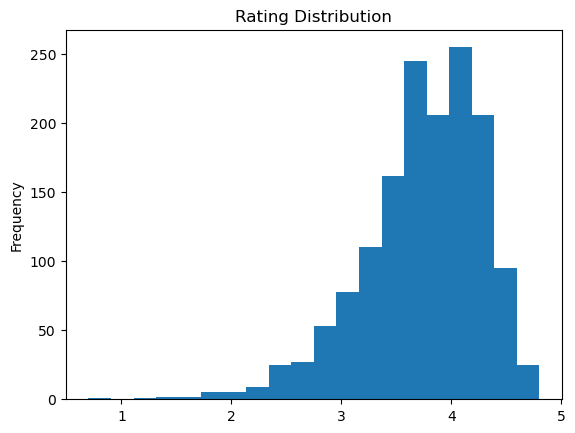

In [28]:
games['Rating'].plot(kind='hist', bins=20)
plt.title('Rating Distribution')
plt.show()

•	Most games are rated between 3.5–4.5
•	Most games fall between X–Y rating
•	Very few extremely low/high ratings

## Engagement vs Rating 🔥⭐

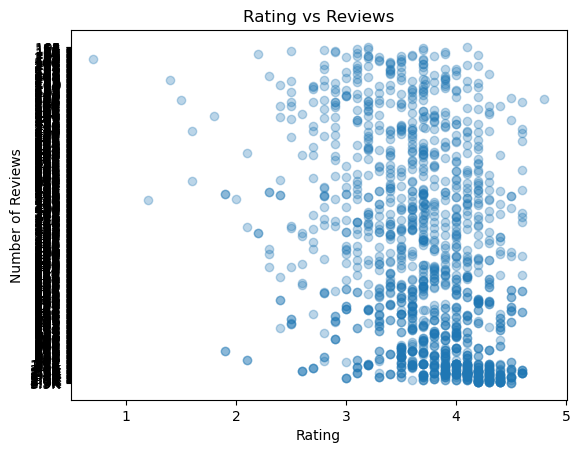

In [34]:
plt.scatter(games['Rating'], games['Number of Reviews'], alpha=0.3)
plt.xlabel('Rating')
plt.ylabel('Number of Reviews')
plt.title('Rating vs Reviews')
plt.show()

•	No strong correlation between rating and reviews
•	Some low-rated games still have high engagement

## Top Genres Analysis 🎮

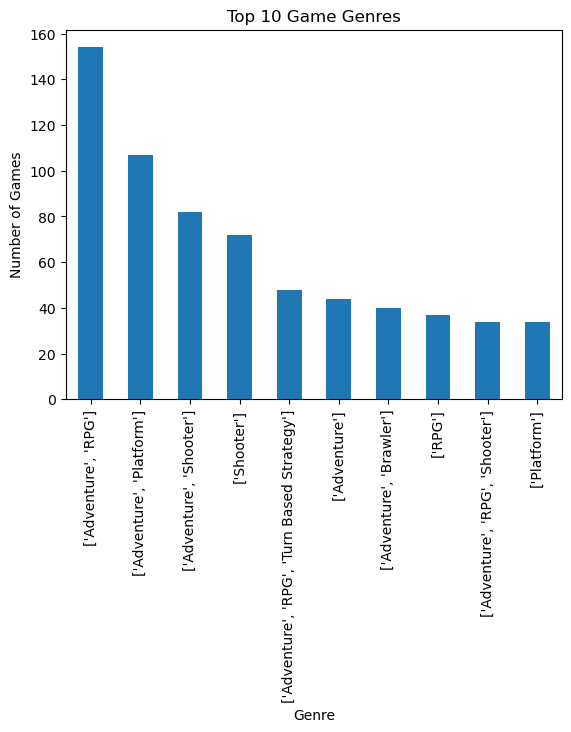

In [30]:
genre_counts = games['Genres'].value_counts().head(10)

genre_counts.plot(kind='bar')
plt.title('Top 10 Game Genres')
plt.xlabel('Genre')
plt.ylabel('Number of Games')
plt.show()

## Top Reviewed Games 🔥

In [33]:
top_games = games.sort_values(by='Number of Reviews', ascending=False).head(10)

print(top_games[['Title', 'Number of Reviews']])

                                                  Title Number of Reviews
507   Phoenix Wright: Ace Attorney - Trials and Trib...               995
240   Phoenix Wright: Ace Attorney - Trials and Trib...               995
166                                  Persona 5 Strikers               993
449                               New Super Mario Bros.               991
160                               New Super Mario Bros.               991
1139                                        Hyper Demon                99
1489                      Kingdoms of Amalur: Reckoning                99
867             Dark Souls II: Scholar of the First Sin               988
121             Dark Souls II: Scholar of the First Sin               988
401             Dark Souls II: Scholar of the First Sin               988


## Average Rating per Year

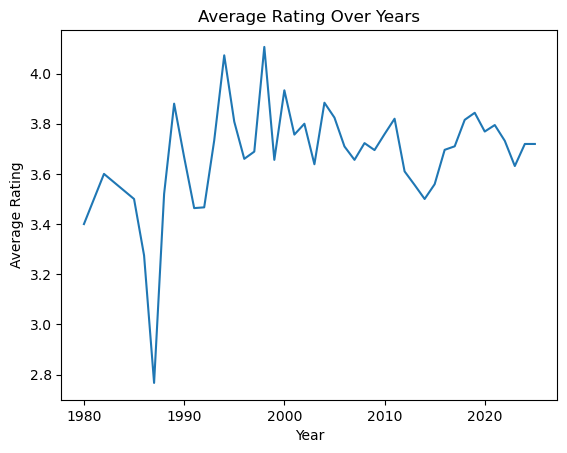

In [35]:
avg_rating = games.groupby('Year')['Rating'].mean()

avg_rating.plot(kind='line')
plt.title('Average Rating Over Years')
plt.xlabel('Year')
plt.ylabel('Average Rating')
plt.show()

## Correlation

In [37]:
games['Number of Reviews'] = pd.to_numeric(games['Number of Reviews'], errors='coerce')

In [38]:
games[['Rating', 'Number of Reviews']].corr()

,Rating,Number of Reviews
Rating,1.000000,0.226665
Number of Reviews,0.226665,1.000000


• The correlation between rating and number of reviews is approximately 0.22  
• This indicates a weak positive relationship  
• Ratings do not strongly determine a game's popularity

## Conclusion 🧠

This project analyzed video game sales and engagement data.

After cleaning the dataset and handling missing values, various visualizations were created to understand trends.

The analysis shows that:
- The number of games has increased significantly over the years
- Popularity (reviews) does not always correlate with ratings
- Certain genres dominate the gaming industry

Overall, the gaming industry has grown rapidly, with increasing user engagement and diverse game genres.